# Module 02: A Box Model Carbon Assignment

### 1. Introduction

In the accompanying notebook [mod02-CarbonModel1.ipynb](./mod02-CarbonModel1.ipynb) and in class we developed a relatively simple model of global carbon balance that assumed that tracked carbon in the atmosphere and biosphere. The system of equations we developed to describe this system are shown below,

$$
\begin{align*}
\frac{dM_1}{dt} &= F_{21} - F_{12}\\
&= k_{21}M_2 - k_{12}M_1
\end{align*}
$$

and,

$$
\begin{align*}
\frac{dM_2}{dt} &= F_{12} - F_{21}\\
&= k_{12}M_1 - k_{21}M_2
\end{align*}
$$

where $M_1$ is the mass of carbon in the atmosphere (GtC), $M_2$ is the mass of carbon in the biosphere (GtC), $F_{12}$ is the flux of carbon from the atmosphere to the biosphere due to photosynthesis (GtC/yr), and $F_{21}$ is the flux of carbon from the biosphere to the atmosphere due to decay and respiration (GtC/yr).

In that notebook we develop a numerical model to describe that system, run it for given initial conditions and with no external inputs of carbon (we call this an "unforced" scenario) and compare it to the analytical solution. We observed that as the time step increased, we departed further from the analytical solution. 

In this assignment you will take your model one step more realistic by ensuring that the photosynthetic flux depends on both the amount of carbon in the atmosphere and in the biosphere. Then you will examine the impact of anthropogenic emissions from 1751-2008 on the biosphere and atmosphere, and how alternative future scenarios of emissions mitigation affect your system. 

The code cell below contains a couple of new commands and some file names that you will need in this assignment. You will need all of these commands, _but not necessarily

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#historical_emissions_file = 'AnthropogenicEmissions.1751_2008.csv'
#data = np.loadtxt(historical_emissions_file, delimiter=',', skiprows=1) #reads a txt file which is often comma-delimited
# Read this documentation to understand what this command does: 
#    https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html
#year = data[:,0]
##cflux = data[:,1]
#
#cflux_t = np.interp(t, year, cflux)
# Read this documentation to understand what this command does: 
#    https://numpy.org/doc/stable/reference/generated/numpy.interp.html

#np.diff(M1)
# Read this documentation to understand what this command does: 
#    https://numpy.org/doc/stable/reference/generated/numpy.diff.html

## 2. Assignment Tasks

For all plots, label all axes and provide units.

__Problem A: Modify and rerun the model__

1. Modify the model so that the photosynthesis flux includes the mass of carbon in the land (i.e., $M_1$). Use the following parameters:

  * $M_1^0$ = 1100.0 
  * $M_2^0$ = 300.0 
  * $k_{12}$ = 0.0003 
  * $k_{21}$ = 0.1  

2. Repeat the "unforced" (i.e., no anthropogenic emissions) simulation above, but run the model for `t = 100` years with a daily time step (i.e., `dt = 1/365`)
3. Use the `print()` command to print out the value of $M_1$ and $M_2$ at the end of the simulation

__Problem B: Examine impacts of human emissions__

1. Load the anthropogenic emissions data for 1751-2008 (see numpy `np.loadtxt()` command usage [here](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html)). Note that the data is in a comma separated variable file (named `AnthropogenicEmissions.1751_2008.csv`) with one header row.
2. Plot the anthropogenic emissions data  
3. Starting from the initial conditions ($M_1^0$ and $M_2^0$) corresponding to the final conditions noted in part __A(3)__ above, simulate the response of the carbon system to the anthropogenic emissions from 1751 to 2008 by adding an appropriate source term in the system of equations. Create the following plots:

  * Mass of C in the atmosphere versus time 
  * Mass of C in the land versus time 
  * The change in mass of C in the atmosphere vs time 
  * The change in mass of C in the biosphere vs time 
    
4. Use the `print()` command to print out the value of $M_1$ and $M_2$ at the end of the simulation in 2008.

__Problem C: Examine the effects of mitigation__

1. Load the alternative emission scenarios contained in the file `.csv`, which represent three pathways to net zero emissions: (a) net zero emissions by the year 2030 (column 2), (c) net zero emissions by 2050 (column 3), and zero emissions growth (i.e., constant emissions) starting in 2008 (column 4).
2. Starting from the initial conditions ($M_1^0$ and $M_2^0$) corresponding to the final conditions noted in part __B(4)__ above, run the model three times, one for each scenario. Create the following plots: 

  * Mass of C in the atmosphere versus time (all three scenarios on one plot)
  * Mass of C in the land versus time (all three scenarios on one plot)
  * The change in mass of C in the atmosphere vs time 
  * The change in mass of C in the biosphere vs time 


# Problem A

In [5]:

import numpy as np
import matplotlib.pyplot as plt

M1i = 1100.0 #initial land mass carbon
M2i = 300.0 #initial atmosphere mass carbon

k12 = 0.0003 #land to atmosphere flux
k21 = 0.1 #atmosphere to land flux

ti = 0.0 #initial time
tf = 100 #length of time (years)
dt = 1/365 #step of time (days)

t = np.arange(ti,tf+dt,dt) 

Nt = t.size #nt is vector that we can now use to set the length of the rest of our dataframes for the toy model

print('t has '+str(Nt)+' time steps')

M1a = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values
M2a = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values

t has 36501 time steps


In [6]:
#initialize the model from t = 0 to t = 20


for i in np.arange(Nt):
    if (i==0): #at 0 time, use our initial conditions

        M1a[i] = M1i
        M2a[i] = M2i
        
    else: #if not 0 time, we need to evaluate the in and out flux for each bucket
        dM1dt = k21*M2a[i-1] - k12*M1a[i-1]*M1a[i-1] #land flux (atmosphere deposition/photosynthesis minus fire/respiration) -> total flux for period t-1
        dM2dt = k12*M1a[i-1]*M1a[i-1] - k21*M2a[i-1] #atmosphere flux (fire/respiration input minus deposition/photosynthesis output) from previous year)
        
        M1a[i] = M1a[i-1] + dM1dt*dt #previous condition plus total flux = mass carbon at Nt(i)
        M2a[i] = M2a[i-1] + dM2dt*dt

print(M1a[-1])
print(M2a[-1])

536.500770324349
863.4992296756521


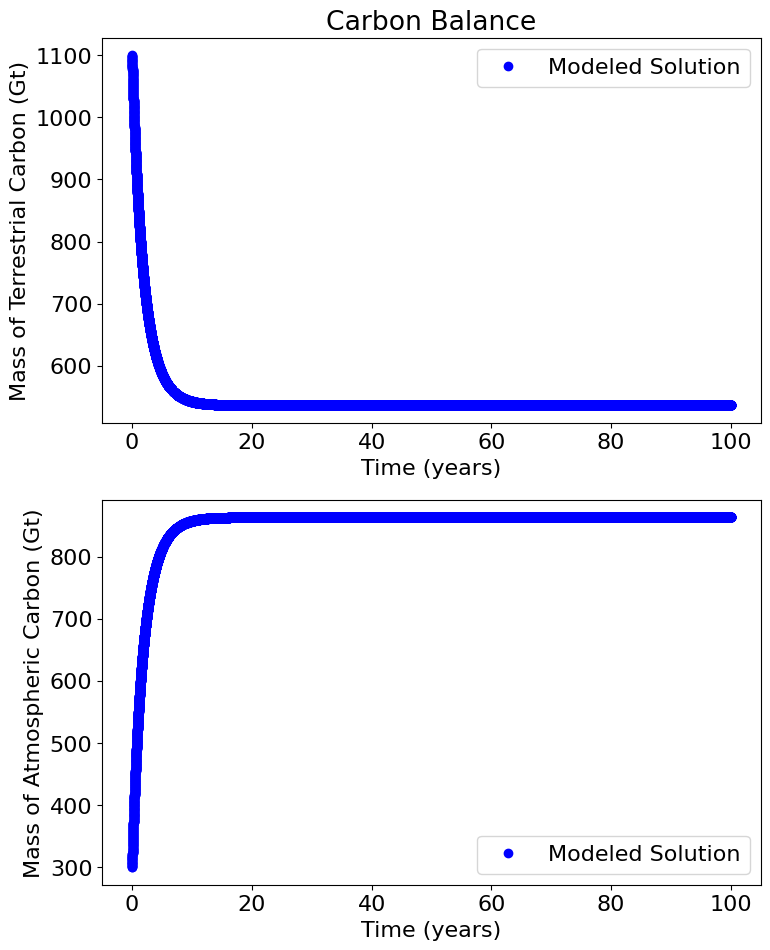

In [7]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('Carbon Balance')
plt.plot(t,M1a,'bo', label='Modeled Solution')
#plt.plot(t,M1_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Mass of Terrestrial Carbon (Gt)')
plt.legend()

plt.subplot(2,1,2)
plt.plot(t,M2a,'bo', label='Modeled Solution')
#plt.plot(t,M2_anlt,'k-', label='Analytical Solution')
plt.xlabel('Time (years)')
plt.ylabel('Mass of Atmospheric Carbon (Gt)')
plt.legend()

plt.show()

# Problem B

In [8]:
import numpy as np
import matplotlib.pyplot as plt

historical_emissions_file = 'AnthropogenicEmissions.1751_2008.csv'
data = np.loadtxt(historical_emissions_file, delimiter=',', skiprows=1)
year = data[:,0]
cflux = data[:,1]

M1i = M1a[-1] #initial land mass carbon at end of spin up model
M2i = M2a[-1] #initial atmosphere mass carbon at end of spin up model

k12 = 0.0003 #land to atmosphere flux
k21 = 0.1 #atmosphere to land flux

#ti = year[0] #initial time of 1751 borrowing from our file
#tf = len(year) #length of time (years) (should be 258)
dt = 1/365 #step of time (days) 
t = np.arange(year[0], year[0] + len(year), dt) #make t as long as we need to get daily cflux -> should be 365*258
cflux_t = np.interp(t, year, cflux) #daily cflux interpolated from annual cflux in file

Nt = t.size

M1b = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values
M2b = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values

#np.diff(M1)
# Read this documentation to understand what this command does: 
#    https://numpy.org/doc/stable/reference/generated/numpy.diff.html

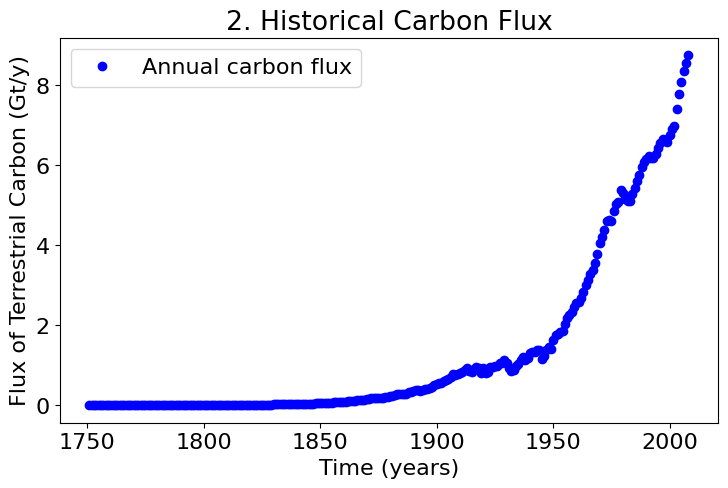

In [9]:
plt.figure(figsize=(8.5,11))
plt.rcParams.update({'font.size': 16})

plt.subplot(2,1,1)
plt.title('2. Historical Carbon Flux')
plt.plot(year,cflux,'bo', label='Annual carbon flux')
plt.xlabel('Time (years)')
plt.ylabel('Flux of Terrestrial Carbon (Gt/y)')
plt.legend()
plt.show()


In [10]:
#initialize the model from year[0]
for i in np.arange(Nt):
    if (i==0): #at 0 time, use our initial conditions

        M1b[i] = M1i
        M2b[i] = M2i
        
    else: #if not 0 time, we need to evaluate the in and out flux for each bucket
        dM1bdt = k21*M2b[i-1] - k12*M1b[i-1]*M1b[i-1] #land flux (atmosphere deposition/photosynthesis minus fire/respiration) -> total flux for period t-1
        dM2bdt = k12*M1b[i-1]*M1b[i-1] - k21*M2b[i-1] #atmosphere flux (fire/respiration input minus deposition/photosynthesis output) from previous year)
        
        M1b[i] = M1b[i-1] + dM1bdt*dt  #previous condition plus total flux = mass carbon at Nt(i)
        M2b[i] = M2b[i-1] + dM2bdt*dt +cflux_t[i-1]*dt

        
dM1dt_diff = np.diff(M1b) / np.diff(t) #daily change in delta  
dM2dt_diff = np.diff(M2b) / np.diff(t) #daily change in delta

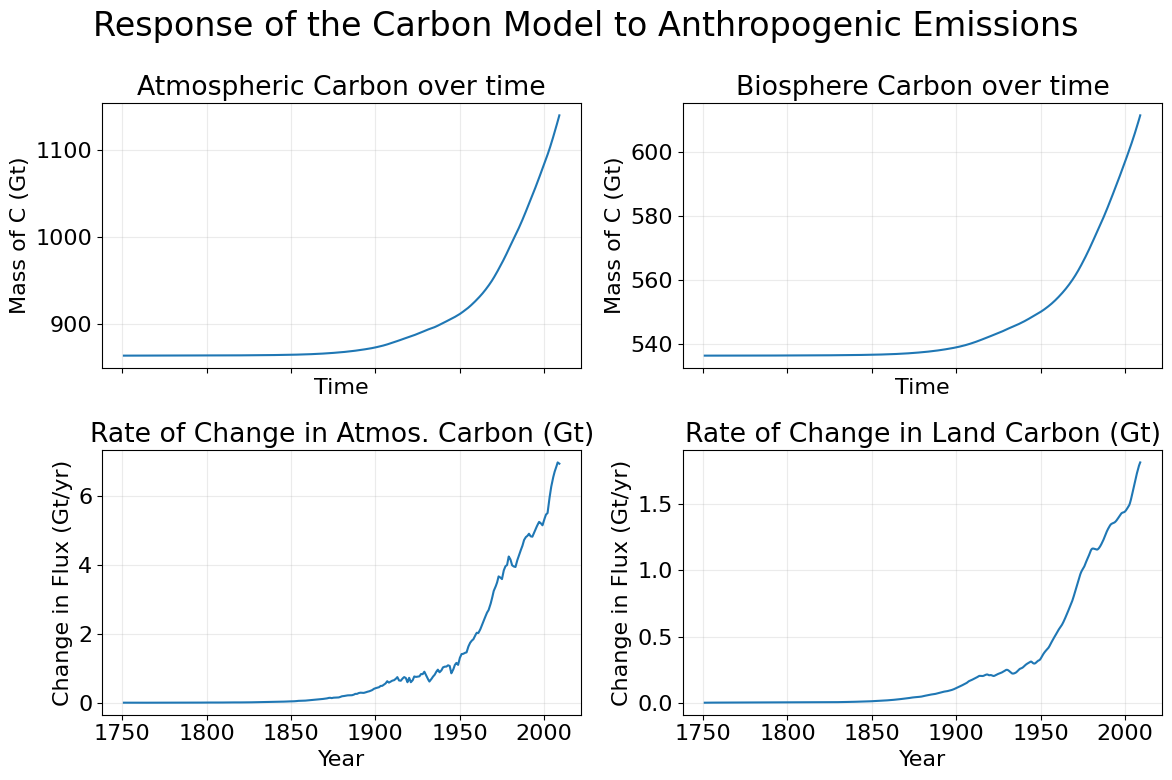

In [11]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
)

fig.suptitle('Response of the Carbon Model to Anthropogenic Emissions',
             fontsize=24) # add a SUPER title

#mass of C in atmosphere versus time
ax[0,0].plot(t,M2b)
ax[0,0].set_ylabel('Mass of C (Gt)')
ax[0,0].set_xlabel('Time')
ax[0,0].set_title('Atmospheric Carbon over time')

#Mass of C in the land versus time
ax[0,1].plot(t,M1b)
ax[0,1].set_ylabel('Mass of C (Gt)')
ax[0,1].set_xlabel('Time')
ax[0,1].set_title('Biosphere Carbon over time')

#Change in mass of C in atmosphere verus time
ax[1,0].plot(t[1:],dM2dt_diff)
ax[1,0].set_xlabel('Year')
ax[1,0].set_ylabel('Change in Flux (Gt/yr)')
ax[1,0].set_title('Rate of Change in Atmos. Carbon (Gt)')

#Change in mass of C in biosphere versus time
ax[1,1].plot(t[1:],dM1dt_diff)
ax[1,1].set_xlabel('Year')
ax[1,1].set_ylabel('Change in Flux (Gt/yr)')
ax[1,1].set_title('Rate of Change in Land Carbon (Gt)')
for a in ax.flat:
    a.grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [12]:
print(f"Terrestrial carbon: {M1b[-1]:.3f} Gt C")
print(f"Atmospheric carbon: {M2b[-1]:.3f} Gt C")

Terrestrial carbon: 611.424 Gt C
Atmospheric carbon: 1139.671 Gt C


# Problem C

In [13]:
future_emissions_file = 'EmissionsMitigationScenarios.2008_2100.csv'

data = np.loadtxt(future_emissions_file, delimiter=',', skiprows=1)
year = data[:,0] # read column 1 as year
cflux_nz2030 = data[:,1] # read column 2 as 2030 scenario where we really should be
cflux_nz2050 = data[:,2] # read column 3 as 2050 scenario where we really need to be
cflux_zeg = data[:,3] # read column 4 as if we stay in Drill Baby Drill! mode

M1i = M1b[-1] #initial land mass carbon at end of spin up model
M2i = M2b[-1] #initial atmosphere mass carbon at end of spin up model

k12 = 0.0003 #land to atmosphere flux
k21 = 0.1 #atmosphere to land flux

dt = 1/365 #step of time (days) 
t = np.arange(year[0], year[0] + len(year), dt) #make t as long as we need to get daily cflux -> should be 365*92
cflux_30 = np.interp(t, year, cflux_nz2030) #daily cflux interpolated from annual cflux in file
cflux_50 = np.interp(t, year, cflux_nz2050)
cflux_cons = np.interp(t, year, cflux_zeg)

Nt = t.size

scenarios = { # Store the three future emissions scenarios in a dictionary
    'Net Zero 2030': cflux_30,
    'Net Zero 2050': cflux_50,
    'Constant Emissions': cflux_cons
}

results = {} # Empty dictionary to store model outputs

Trying out dictionaries here. Instead of just creating a list to loop through, I can start creating hierarchical storage for my variables under named key/pair combinations. Naming the keys is easier than interpretting positions in a list if the models get complex or we evaluate lots of scenarios - just a bit of housekeeping. 

In [14]:
for scenario, cflux_future in scenarios.items(): # we have three scenarios - lets loop through them 
    #this works because we have a key-value pair. when we loop through Net Zero 2030, we retrieve clux_30; etc. 
    M1c = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values
    M2c = np.zeros((Nt,)) #land mass carbon empty dataframe so we can start storing M1[t] values

    #initialize the model from year[0]
    for i in np.arange(Nt):
        if (i==0): #at 0 time, use our initial conditions - not really necessary anymore but thats okay
            M1c[i] = M1i
            M2c[i] = M2i
        else: #if not 0 time, we need to evaluate the in and out flux for each bucket
            dM1cdt = k21*M2c[i-1] - k12*M1c[i-1]*M1c[i-1] #land flux (atmosphere deposition/photosynthesis minus fire/respiration) -> total flux for period t-1
            dM2cdt = k12*M1c[i-1]*M1c[i-1] - k21*M2c[i-1] #atmosphere flux (fire/respiration input minus deposition/photosynthesis output) from previous year)
        
            M1c[i] = M1c[i-1] + dM1cdt*dt  #previous condition plus total flux = mass carbon at Nt(i)
            M2c[i] = M2c[i-1] + dM2cdt*dt +cflux_future[i-1]*dt

        
    dM1dt_diff = np.diff(M1c) / np.diff(t) #daily change in delta  
    dM2dt_diff = np.diff(M2c) / np.diff(t) #daily change in delta

    results[scenario] = {
        'cflux': cflux_future,
        'M1': M1c,
        'M2': M2c,
        'dM1dt': dM1dt_diff,
        'dM2dt': dM2dt_diff
    }

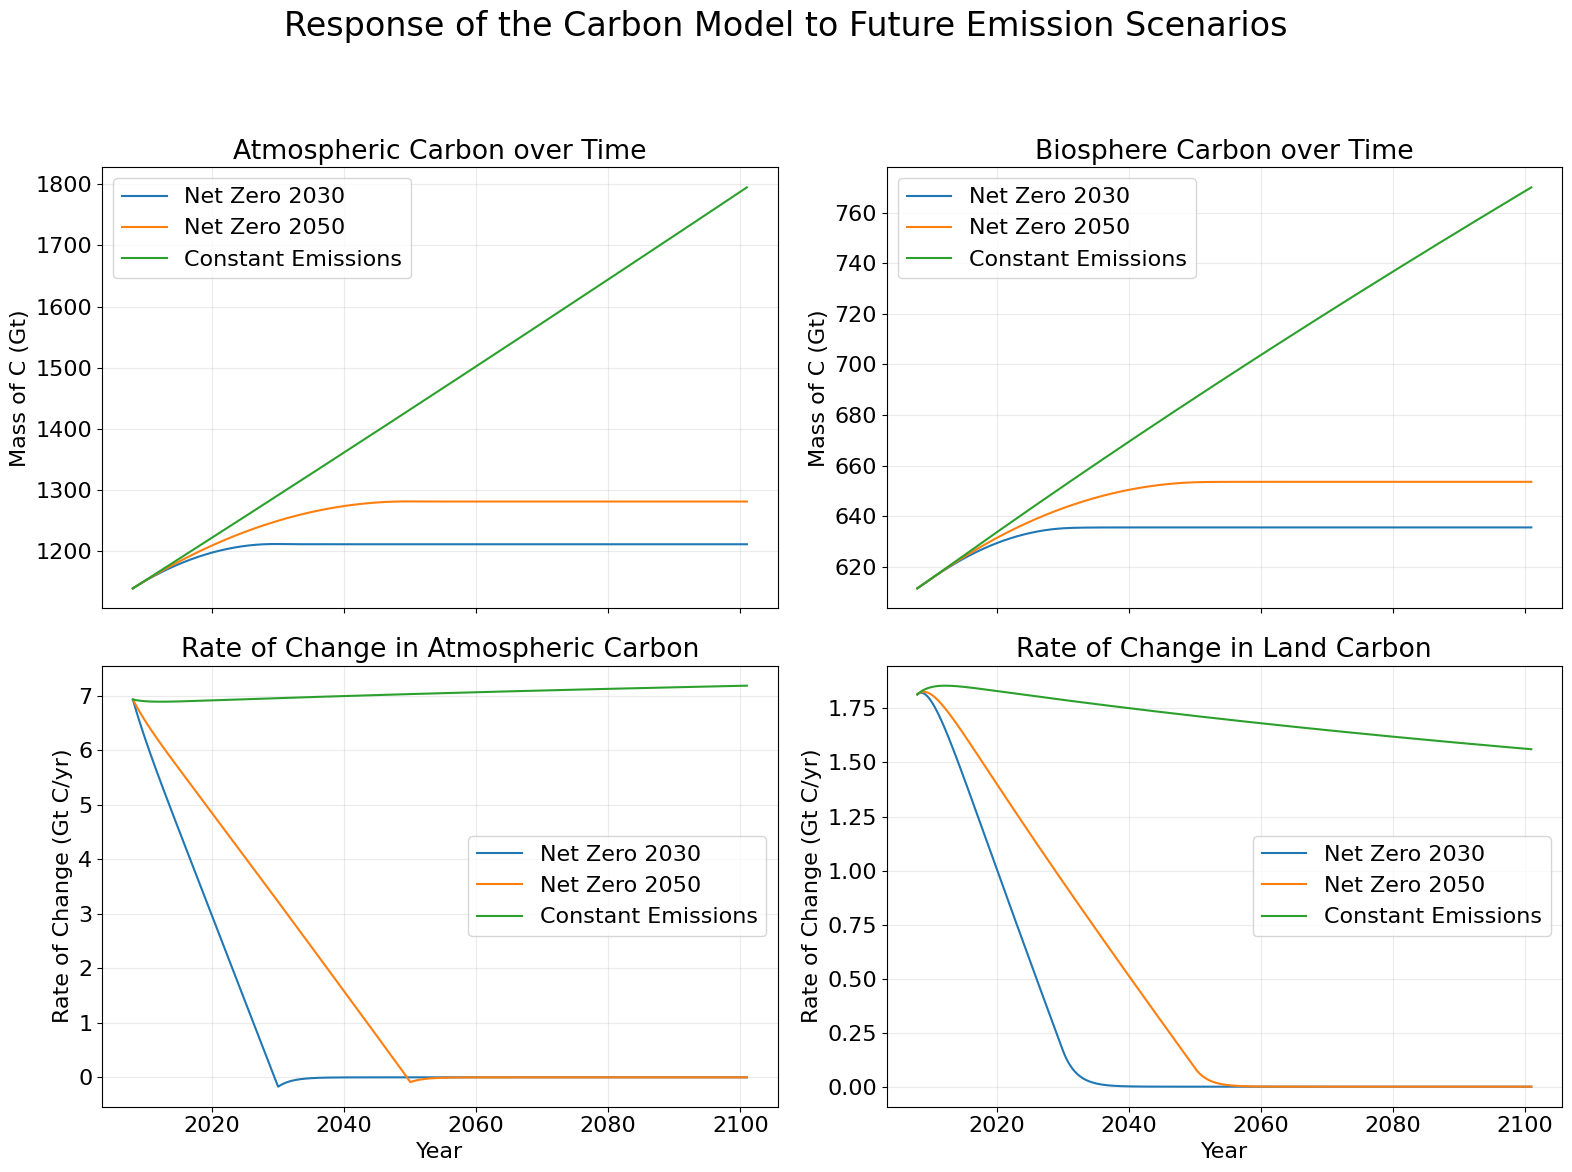

In [15]:
fig, ax = plt.subplots(
    2, 2,
    figsize=(16, 12),
    sharex=True
)

fig.suptitle(
    'Response of the Carbon Model to Future Emission Scenarios',
    fontsize=24
)

# Add all three scenarios
for scenario in results:
    ax[0,0].plot(t,results[scenario]['M2'],label=scenario) # plot atmosphere
    ax[0,1].plot(t,results[scenario]['M1'],label=scenario) # plot biosphere
    ax[1,0].plot(t[1:], results[scenario]['dM2dt'], label=scenario) # plot atmosphere rate
    ax[1,1].plot(t[1:], results[scenario]['dM1dt'], label=scenario) # plot biosphere rate

# Titles and labels
ax[0,0].set_title('Atmospheric Carbon over Time')
ax[0,0].set_ylabel('Mass of C (Gt)')
ax[0,0].legend()
ax[0,0].grid(alpha = 0.25)

ax[0,1].set_title('Biosphere Carbon over Time')
ax[0,1].set_ylabel('Mass of C (Gt)')
ax[0,1].legend()
ax[0,1].grid(alpha = 0.25)

ax[1,0].set_title('Rate of Change in Atmospheric Carbon')
ax[1,0].set_xlabel('Year')
ax[1,0].set_ylabel('Rate of Change (Gt C/yr)')
ax[1,0].legend()
ax[1,0].grid(alpha = 0.25)

ax[1,1].set_title('Rate of Change in Land Carbon')
ax[1,1].set_xlabel('Year')
ax[1,1].set_ylabel('Rate of Change (Gt C/yr)')
ax[1,1].legend()
ax[1,1].grid(alpha = 0.25)

fig.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()